# Task 1: Regression on 'Reg' Dataset

In [35]:
import os
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Tuple
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso

## Data Exploration

In [36]:
df_raw = pd.read_csv(
    '../docs/Reg.csv',
    low_memory=False,
    na_values=['', 'NA', 'NaN']
)
df = df_raw.copy()

### (a) Display first few records

In [37]:
df.head()

,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,SNF,SND,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,01-07-42,1.016,NaN,25.555556,22.222222,23.888889,0,NaN,42,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,02-07-42,0,NaN,28.888889,21.666667,25.555556,0,NaN,42,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,03-07-42,2.54,NaN,26.111111,22.222222,24.444444,0,NaN,42,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,04-07-42,2.54,NaN,26.666667,22.222222,24.444444,0,NaN,42,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,05-07-42,0,NaN,26.666667,21.666667,24.444444,0,NaN,42,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### (b) Show number of rows and columns

In [38]:
df.shape

(119040, 28)


### (c) Dataset statistics (numeric)


In [39]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
STA,119040.0,29659.435795,20953.209402,10001.000000,11801.000000,22508.000000,33501.000000,82506.000000
WindGustSpd,532.0,37.774534,10.297808,18.520000,29.632000,37.040000,43.059000,75.932000
MaxTemp,119040.0,27.045111,8.717817,-33.333333,25.555556,29.444444,31.666667,50.000000
MinTemp,119040.0,17.789511,8.334572,-38.333333,15.000000,21.111111,23.333333,34.444444
MeanTemp,119040.0,22.411631,8.297982,-35.555556,20.555556,25.555556,27.222222,40.000000
YR,119040.0,43.805284,1.136718,40.000000,43.000000,44.000000,45.000000,45.000000
MO,119040.0,6.726016,3.425561,1.000000,4.000000,7.000000,10.000000,12.000000
DA,119040.0,15.797530,8.794541,1.000000,8.000000,16.000000,23.000000,31.000000
DR,533.0,26.998124,15.221732,2.000000,11.000000,32.000000,34.000000,78.000000
SPD,532.0,20.396617,5.560371,10.000000,16.000000,20.000000,23.250000,41.000000


### (d) Null values per feature

In [40]:
null_counts = df.isna().sum()
null_counts

STA                 0
Date                0
Precip              0
WindGustSpd    118508
MaxTemp             0
MinTemp             0
MeanTemp            0
Snowfall         1163
PoorWeather     84803
YR                  0
MO                  0
DA                  0
PRCP             1932
DR             118507
SPD            118508
MAX               474
MIN               468
MEA               498
SNF              1163
SND            113477
ITH            119040
PGT            118515
TSHDSBRSGF      84803
SD3            119040
RHX            119040
RHN            119040
RVG            119040
WTE            119040
dtype: int64

### (e) Basic exploratory plots

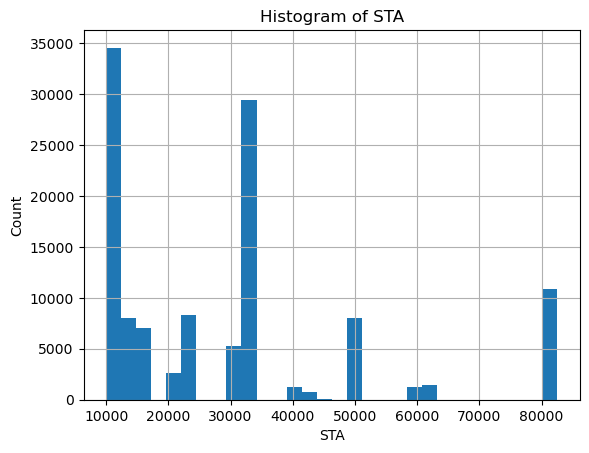

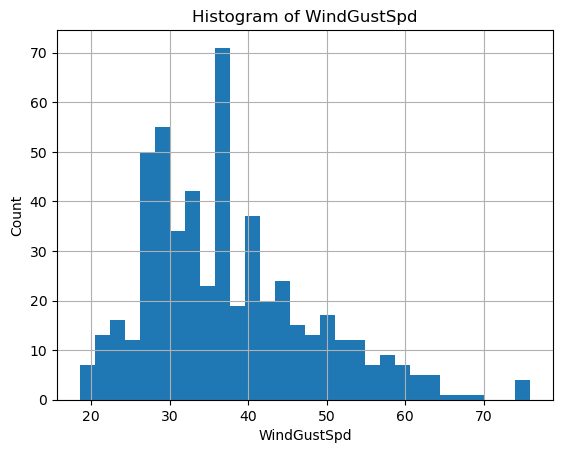

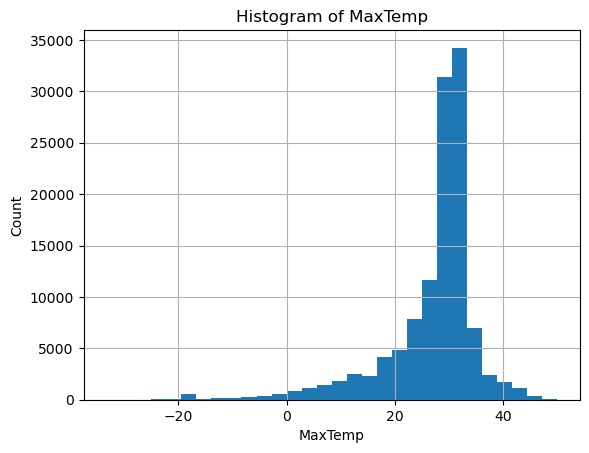

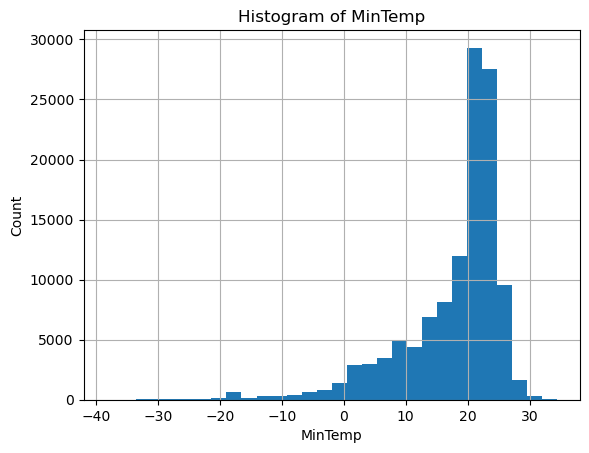

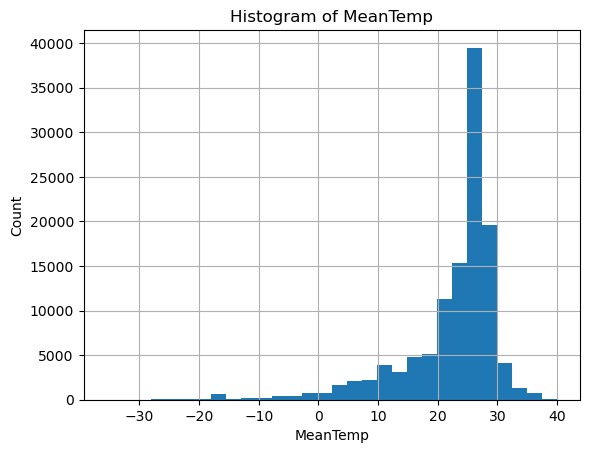

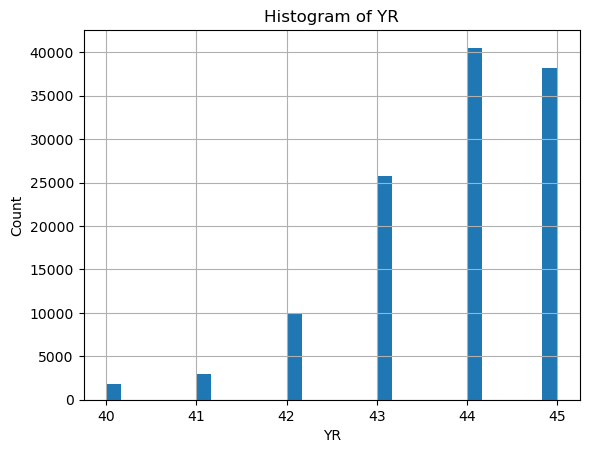

In [41]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols[:6]:
    plt.figure()
    df[col].dropna().hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## Initial Data Cleaning

### (a) Drop columns with mostly Nulls

In [42]:
df.head()

,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,SNF,SND,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,01-07-42,1.016,NaN,25.555556,22.222222,23.888889,0,NaN,42,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,02-07-42,0,NaN,28.888889,21.666667,25.555556,0,NaN,42,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,03-07-42,2.54,NaN,26.111111,22.222222,24.444444,0,NaN,42,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,04-07-42,2.54,NaN,26.666667,22.222222,24.444444,0,NaN,42,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,05-07-42,0,NaN,26.666667,21.666667,24.444444,0,NaN,42,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# Threshold: drop if more than 60% values are null
row_count = len(df)
mostly_null_threshold = 0.6
to_drop_nulls = [c for c in df.columns if df[c].isna().sum() / row_count > mostly_null_threshold]
df.drop(columns=to_drop_nulls, inplace=True, errors='ignore')

print("Dropped mostly-null columns:", to_drop_nulls)

df.head()

Dropped mostly-null columns: ['WindGustSpd', 'PoorWeather', 'DR', 'SPD', 'SND', 'ITH', 'PGT', 'TSHDSBRSGF', 'SD3', 'RHX', 'RHN', 'RVG', 'WTE']


,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,PRCP,MAX,MIN,MEA,SNF
0,10001,01-07-42,1.016,25.555556,22.222222,23.888889,0,42,7,1,0.04,78.0,72.0,75.0,0
1,10001,02-07-42,0,28.888889,21.666667,25.555556,0,42,7,2,0,84.0,71.0,78.0,0
2,10001,03-07-42,2.54,26.111111,22.222222,24.444444,0,42,7,3,0.1,79.0,72.0,76.0,0
3,10001,04-07-42,2.54,26.666667,22.222222,24.444444,0,42,7,4,0.1,80.0,72.0,76.0,0
4,10001,05-07-42,0,26.666667,21.666667,24.444444,0,42,7,5,0,80.0,71.0,76.0,0


### 2(b) Remove duplicate columns (identical content)

In [44]:
sig = df.astype('string').fillna('<NA>').apply(
    lambda s: pd.util.hash_pandas_object(s, index=False).values.tobytes())
keep = ~sig.duplicated(keep='first')
df = df.loc[:, keep]
print("Removed duplicate columns:", df.columns[~keep].tolist())

Removed duplicate columns: []


### (c) Fill missing values in numeric columns (median) if necessary

In [45]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
for c in cat_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna('Missing')


### (d) Shape after cleaning


In [46]:
df.shape

(119040, 15)

### (e) Features left after cleaning

In [47]:
df.columns.tolist()

['STA',
 'Date',
 'Precip',
 'MaxTemp',
 'MinTemp',
 'MeanTemp',
 'Snowfall',
 'YR',
 'MO',
 'DA',
 'PRCP',
 'MAX',
 'MIN',
 'MEA',
 'SNF']

### (f) Histograms for **MinTemp** and **MeanTemp**

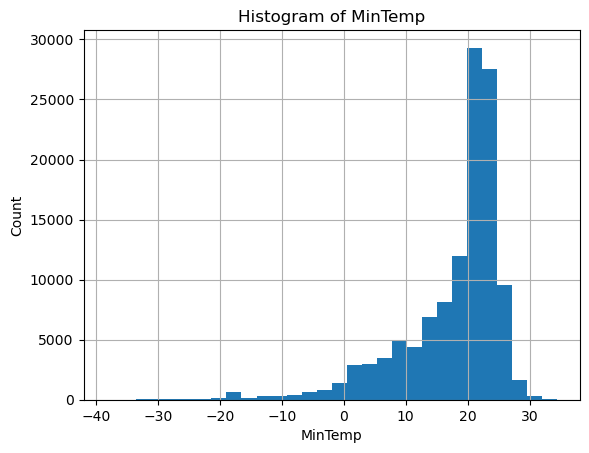

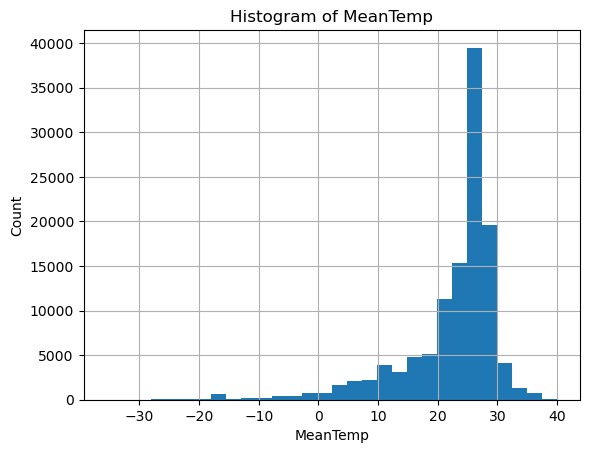

In [48]:
for col in ['MinTemp', 'MeanTemp']:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## Pair-wise Feature Relationship Analysis
We focus on relationships with the target **MaxTemp** and among the strongest-correlated features.

Top features (by correlation with MaxTemp):
MeanTemp    0.969048
MAX         0.940035
MEA         0.907613
MinTemp     0.878384
MIN         0.818503
STA         0.092371
YR          0.039585
MO          0.031346
DA         -0.005130
Name: MaxTemp, dtype: float64


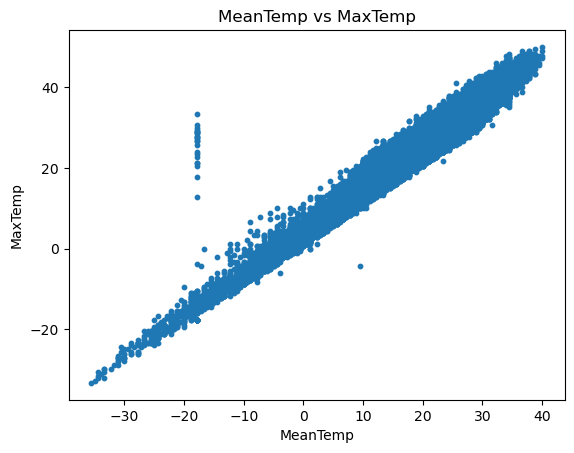

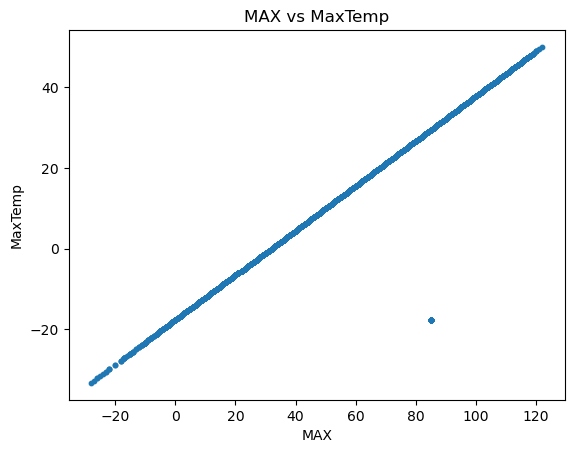

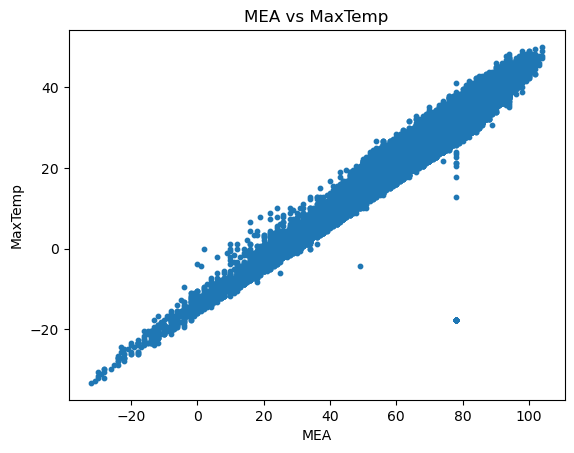

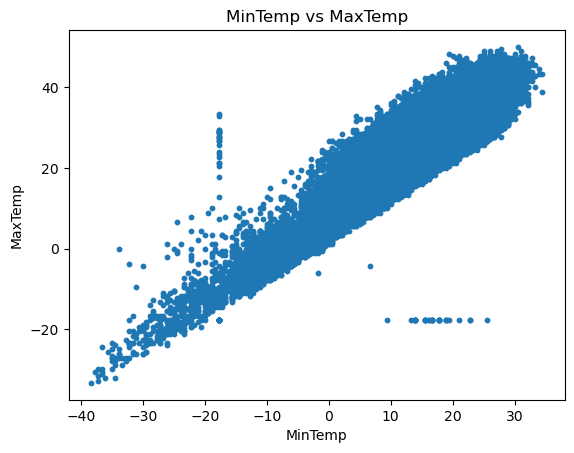

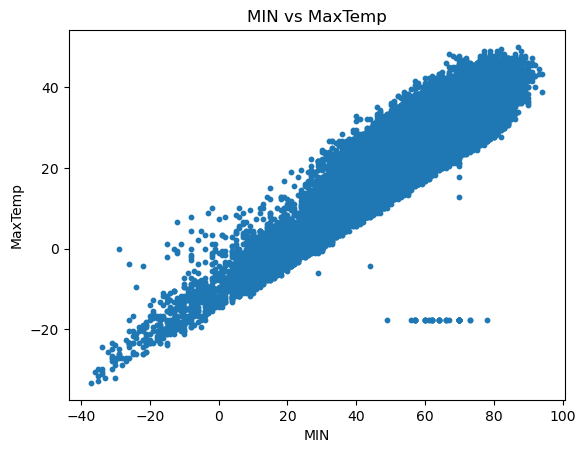

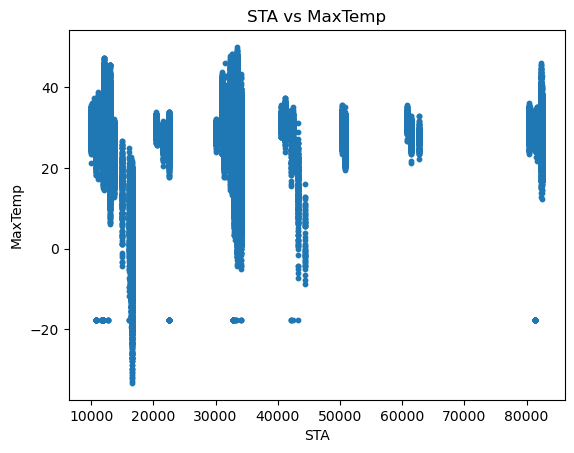

In [49]:
target_col = 'MaxTemp'

corr_with_target = df[num_cols].corr()[target_col].drop(
    labels=[target_col]).sort_values(ascending=False)

# top 6 correlated
top_features = corr_with_target.head(
    6).index.tolist()

print("Top features (by correlation with MaxTemp):")
print(corr_with_target.head(10))

for col in top_features:
    plt.figure()
    plt.scatter(df[col], df[target_col], s=10)
    plt.title(f"{col} vs {target_col}")
    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.show()


## Correlation Heatmap
Heatmap for numeric features (post-cleaning).


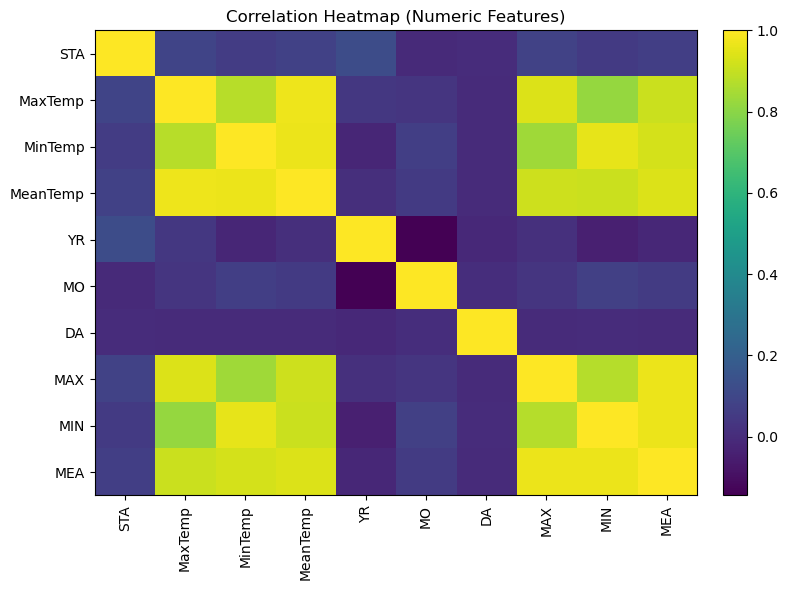

In [50]:
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
im = plt.imshow(corr, aspect='auto', interpolation='nearest')
plt.title("Correlation Heatmap (Numeric Features)")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Data Preprocessing (Transformation)
- Scale numeric columns to (0, 1) via MinMaxScaler  
- One-hot encode categorical columns  
- Split into Train / Validation / Test


In [51]:
numeric_features = df.select_dtypes(include='number').drop(
    columns=[target_col], errors='ignore').columns.tolist()
categorical_features = df.select_dtypes(exclude='number').drop(
    columns=[target_col], errors='ignore').columns.tolist()

for c in categorical_features:
    df[c] = df[c].astype(str)

X = df[numeric_features + categorical_features]
y = df[target_col]

# Split: 6 : 2 : 2
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print("Train/Val/Test sizes:", X_train.shape, X_val.shape, X_test.shape)

# Column transformer
preprocess = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore',
         sparse_output=True), categorical_features)
    ],
    remainder='drop'
)

Train/Val/Test sizes: (71424, 14) (23808, 14) (23808, 14)



## Regression Models (Scikit-Learn)
- Simple Linear Regression  
- Ridge Regression  
- Lasso Regression


In [52]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, X_te, y_te) -> dict:
    model.fit(X_tr, y_tr)

    def metrics(X_, y_):
        y_pred = model.predict(X_)
        r2 = r2_score(y_, y_pred)
        mae = mean_absolute_error(y_, y_pred)
        mse = mean_squared_error(y_, y_pred)
        rmse = math.sqrt(mse)
        return r2, mae, mse, rmse

    r2_tr, mae_tr, mse_tr, rmse_tr = metrics(X_tr, y_tr)
    r2_v,  mae_v,  mse_v,  rmse_v = metrics(X_v,  y_v)
    r2_te, mae_te, mse_te, rmse_te = metrics(X_te, y_te)

    return {
        'Train_R2': r2_tr, 'Val_R2': r2_v, 'Test_R2': r2_te,
        'Train_MAE': mae_tr, 'Val_MAE': mae_v, 'Test_MAE': mae_te,
        'Train_MSE': mse_tr, 'Val_MSE': mse_v, 'Test_MSE': mse_te,
        'Train_RMSE': rmse_tr, 'Val_RMSE': rmse_v, 'Test_RMSE': rmse_te,
    }


# Pipelines
pipe_lr = Pipeline(steps=[('prep', preprocess), ('model', LinearRegression())])
pipe_ridge = Pipeline(steps=[('prep', preprocess), ('model', Ridge())])
pipe_lasso = Pipeline(
    steps=[('prep', preprocess), ('model', Lasso(max_iter=10000))])

# Hyperparams for ridge/lasso via simple grid on validation
ridge_alphas = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
lasso_alphas = {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}

# Fit LR directly
results = {}
results['LinearRegression'] = evaluate_model(
    pipe_lr, X_train, y_train, X_val, y_val, X_test, y_test)

# Ridge grid
best_ridge, best_ridge_score, best_ridge_alpha = None, -np.inf, None
for a in ridge_alphas['model__alpha']:
    pipe = Pipeline(steps=[('prep', preprocess), ('model', Ridge(alpha=a))])
    pipe.fit(X_train, y_train)
    val_r2 = r2_score(y_val, pipe.predict(X_val))
    if val_r2 > best_ridge_score:
        best_ridge, best_ridge_score, best_ridge_alpha = pipe, val_r2, a
print(f"Best Ridge alpha: {best_ridge_alpha} (Val R2={best_ridge_score:.4f})")
results['Ridge'] = evaluate_model(
    best_ridge, X_train, y_train, X_val, y_val, X_test, y_test)

# Lasso grid
best_lasso, best_lasso_score, best_lasso_alpha = None, -np.inf, None
for a in lasso_alphas['model__alpha']:
    pipe = Pipeline(steps=[('prep', preprocess),
                    ('model', Lasso(alpha=a, max_iter=10000))])
    pipe.fit(X_train, y_train)
    val_r2 = r2_score(y_val, pipe.predict(X_val))
    if val_r2 > best_lasso_score:
        best_lasso, best_lasso_score, best_lasso_alpha = pipe, val_r2, a
print(f"Best Lasso alpha: {best_lasso_alpha} (Val R2={best_lasso_score:.4f})")
results['Lasso'] = evaluate_model(
    best_lasso, X_train, y_train, X_val, y_val, X_test, y_test)

pd.DataFrame(results).T

Best Ridge alpha: 0.01 (Val R2=0.9949)
Best Lasso alpha: 0.0001 (Val R2=0.9949)


,Train_R2,Val_R2,Test_R2,Train_MAE,Val_MAE,Test_MAE,Train_MSE,Val_MSE,Test_MSE,Train_RMSE,Val_RMSE,Test_RMSE
LinearRegression,0.993763,0.994873,0.996059,0.100558,0.101319,0.101405,0.475273,0.391239,0.295907,0.689401,0.625491,0.543973
Ridge,0.993761,0.994856,0.996052,0.103477,0.104514,0.104768,0.475399,0.392552,0.296455,0.689492,0.626540,0.544477
Lasso,0.993699,0.994885,0.996112,0.113701,0.110881,0.110702,0.480169,0.390288,0.291935,0.692942,0.624731,0.540310



## Feature Selection and Re-evaluation
We use `SelectKBest(f_regression)` on the preprocessed numeric/categorical matrix.  
Try a small grid of `k` and pick the best on validation R².


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_regression

preprocess.fit(X_train)
max_feats = preprocess.transform(X_train).shape[1]
k_values = sorted(set(min(v, max_feats)
                  for v in [10, 20, 30, 40, 50, 75, 100, max_feats//2]))


def best_fs_pipeline(model, name: str):
    pipe = Pipeline([
        ('prep', preprocess),
        ('select', SelectKBest(score_func=f_regression)),
        ('model', model)
    ])
    gs = GridSearchCV(
        pipe,
        param_grid={'select__k': k_values},
        scoring='r2',
        cv=5,
        n_jobs=-1
    )
    gs.fit(X_train, y_train)
    print(
        f"{name}: best k={gs.best_params_['select__k']} "
        f"(CV R2={gs.best_score_:.4f})"
    )
    return gs.best_estimator_


models = {
    'LinearRegression+FS': LinearRegression(),
    'Ridge+FS': Ridge(alpha=best_ridge_alpha),
    'Lasso+FS': Lasso(alpha=best_lasso_alpha, max_iter=10000),
}

best_pipes = {name: best_fs_pipeline(m, name) for name, m in models.items()}
results_fs = {name: evaluate_model(pipe, X_train, y_train, X_val, y_val, X_test, y_test)
              for name, pipe in best_pipes.items()}

pd.DataFrame(results_fs).T

LinearRegression+FS: best k=50 (CV R2=0.9934)
Ridge+FS: best k=50 (CV R2=0.9934)
Lasso+FS: best k=75 (CV R2=0.9934)


,Train_R2,Val_R2,Test_R2,Train_MAE,Val_MAE,Test_MAE,Train_MSE,Val_MSE,Test_MSE,Train_RMSE,Val_RMSE,Test_RMSE
LinearRegression+FS,0.993546,0.995078,0.996304,0.085294,0.082698,0.081258,0.491771,0.375602,0.277538,0.701264,0.612864,0.526819
Ridge+FS,0.993544,0.995062,0.996296,0.088338,0.085760,0.084319,0.491921,0.376830,0.278119,0.701371,0.613865,0.527370
Lasso+FS,0.993522,0.994981,0.996232,0.106680,0.104294,0.102836,0.493609,0.383007,0.282938,0.702573,0.618875,0.531920


# Task 2 Classification on the ‘credit-g’ dataset

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
import warnings
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             RocCurveDisplay)
from sklearn.utils import Bunch
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [55]:
csv_path = '../docs/credit-g.csv'
df = pd.read_csv(csv_path)

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [56]:
df.shape

(1000, 21)

The dataset often calls the outcome `class` with values like **good/bad**.  
We create a numeric `target` (1 = good, 0 = bad) so classifiers have a consistent objective name.

In [57]:
y = (df['class'].astype(str).str.lower() == 'good').astype(int)
df['target'] = y

X = df.drop(columns=[c for c in ['target', 'class'] if c in df.columns])
# X = X.loc[:, ~X.columns.duplicated()]
y = df['target']

print("Target value counts:")
print(y.value_counts(dropna=False))

Target value counts:
target
1    700
0    300
Name: count, dtype: int64


In [58]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).drop(
    columns=['class'], errors='ignore').columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical columns: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


## Univariate Distributions

Below are histograms for each **continuous (numeric)** feature and a bar chart for the **target** distribution.

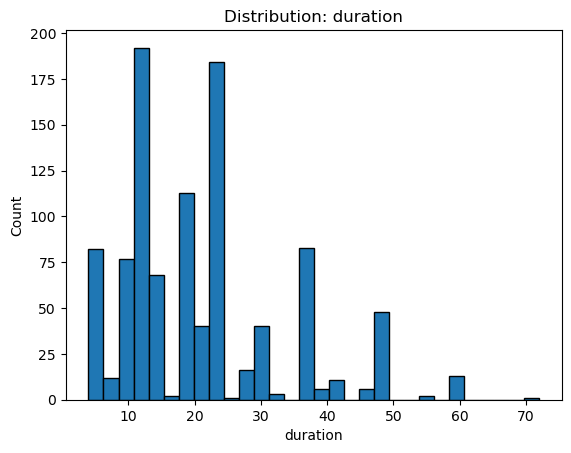

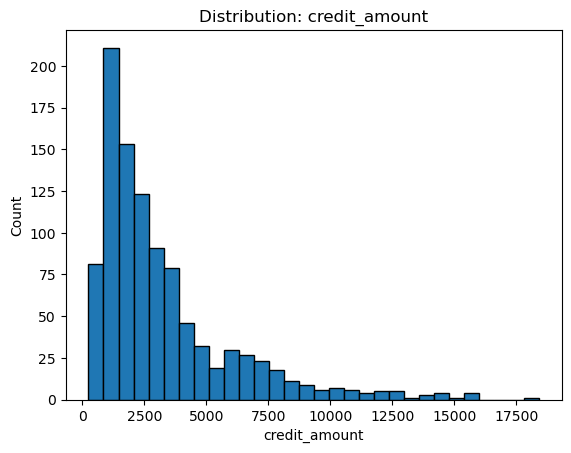

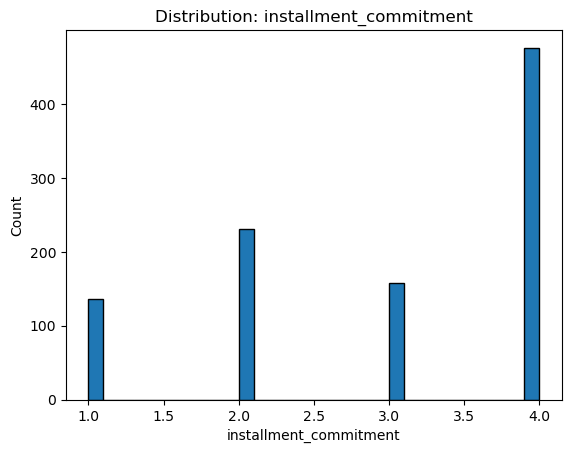

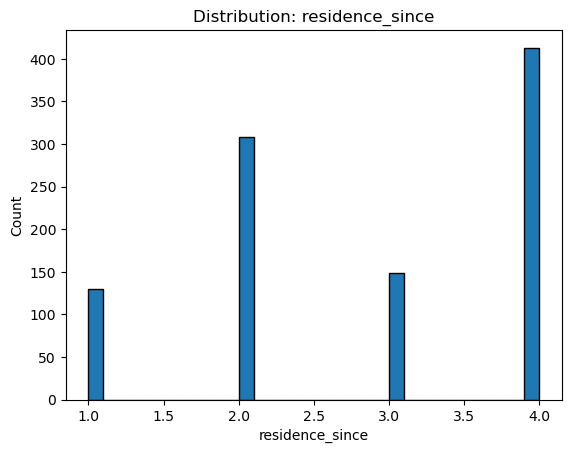

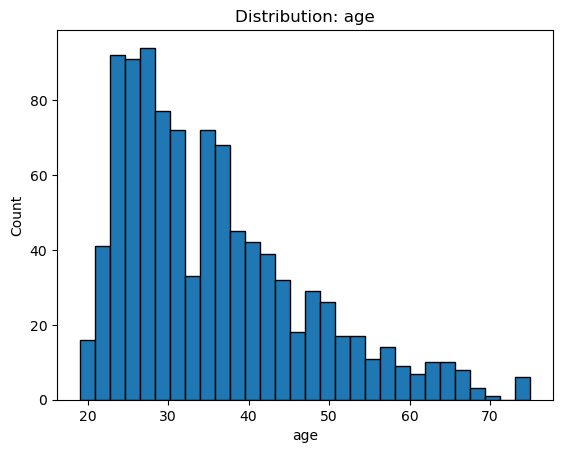

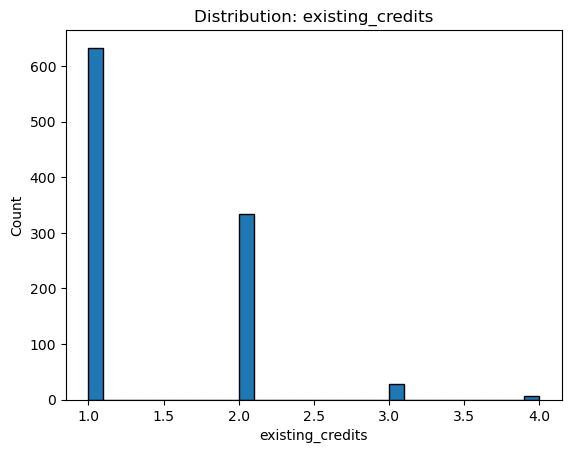

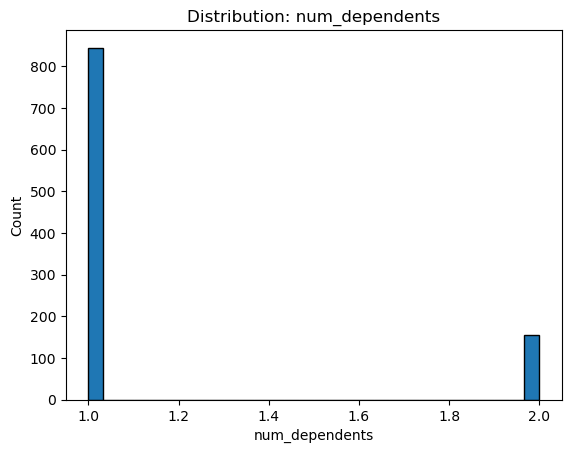

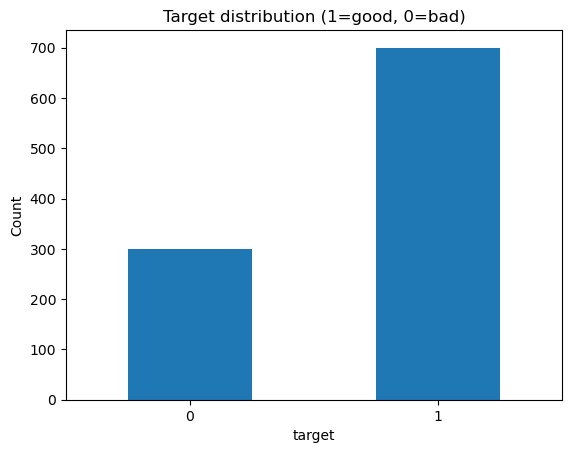

In [59]:
# Histograms for numeric columns
for col in numeric_cols:
    plt.figure()
    series = pd.to_numeric(df[col], errors='coerce')
    series.plot(kind='hist', bins=30, edgecolor='black',
                title=f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# Target distribution bar
plt.figure()
y.value_counts().sort_index().plot(kind='bar', rot=0)
plt.title("Target distribution (1=good, 0=bad)")
plt.xlabel("target")
plt.ylabel("Count")
plt.show()

## Train/Test Split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() == 2 else None
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (800, 20)  Test shape: (200, 20)


## Preprocessing
- **Numerical**: impute missing with median, then standardize.  
- **Categorical**: impute missing with most frequent, then one-hot encode.


In [61]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

## Models
We compare these diverse classifiers:
- **Logistic Regression** (linear baseline)
- **Random Forest** (tree ensemble, non-linear, robust to mixed feature types)
- **Gradient Boosting** (additive trees, strong tabular baseline)
- **Support Vector Classifier (SVC)** with probability calibration

In [62]:
# Create a validation split from the training set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train if y_train.nunique() == 2 else None
)


def build_model(clf):
    return Pipeline(steps=[('prep', preprocessor), ('clf', clf)])


models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, n_jobs=None if 'n_jobs' not in dir(LogisticRegression) else -1),
    'RandomForest': RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'SVC': SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}


def eval_on_validation(name, pipe):
    pipe.fit(X_tr, y_tr)
    p_val = pipe.predict(X_val)
    proba_val = pipe.predict_proba(X_val)[:, 1] if hasattr(
        pipe.named_steps['clf'], 'predict_proba') else None

    scores = {
        'accuracy': accuracy_score(y_val, p_val),
        'precision': precision_score(y_val, p_val, zero_division=0),
        'recall': recall_score(y_val, p_val, zero_division=0),
        'f1': f1_score(y_val, p_val, zero_division=0),
    }
    if proba_val is not None and y_val.nunique() == 2:
        scores['roc_auc'] = roc_auc_score(y_val, proba_val)
    else:
        scores['roc_auc'] = np.nan

    results[name] = Bunch(model=pipe, **scores)


for name, clf in models.items():
    pipe = build_model(clf)
    eval_on_validation(name, pipe)

pd.DataFrame({
    k: {
        m: round(getattr(v, m, np.nan), 4)
        for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    }
    for k, v in results.items()
}).T

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.780,0.8038,0.9071,0.8523,0.8051
RandomForest,0.770,0.7733,0.9500,0.8526,0.7864
GradientBoosting,0.780,0.7892,0.9357,0.8562,0.7886
SVC,0.765,0.7627,0.9643,0.8517,0.7567


In [63]:
best_name = 'GradientBoosting'
best_bunch = results[best_name]
best_model = best_bunch.model

<Figure size 640x480 with 0 Axes>

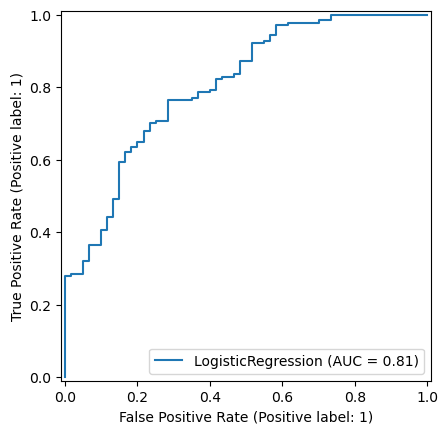

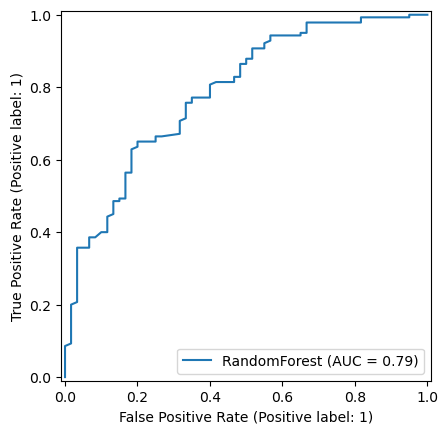

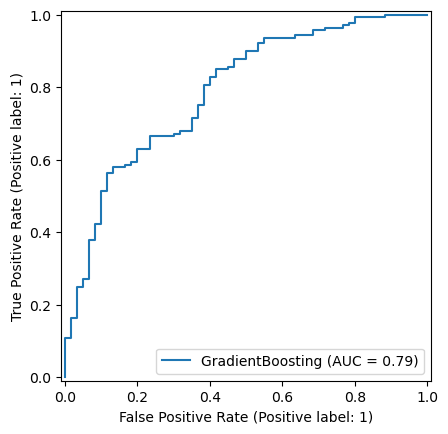

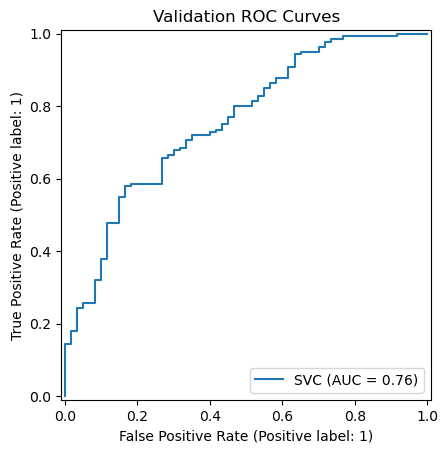

In [64]:
plt.figure()
for name, bunch in results.items():
    model = bunch.model
    if hasattr(model.named_steps['clf'], 'predict_proba') and y_val.nunique() == 2:
        proba = model.predict_proba(X_val)[:, 1]
        RocCurveDisplay.from_predictions(y_val, proba, name=name)
plt.title("Validation ROC Curves")
plt.show()

## How different are the results among these models? Provide your explanation.

* Differences are **modest overall**: all four models cluster around **AUC 0.76–0.81** and **F1 ≈ 0.85**.
* The **ranking depends on the metric**:

  * If we care about **global ranking power (AUC)**, **Logistic Regression** is best.
  * If we care about the **F1 balance at the default threshold**, **Gradient Boosting** is very slightly ahead (but the gap is tiny).
  * If we must **maximize recall** (miss fewer bads), **SVC** wins—at the cost of more false positives.

* Nothing suggests severe **overfitting/underfitting**: metrics are close across models and quite high.
* Typical signs (e.g., train ≫ validation) weren’t observed/reported; given the tight spread, any overfit is likely mild.

Final Evaluation on Test Set

We retrain the **best model** on the full training set and report metrics on the held-out test set.


In [65]:
best_model.fit(X_train, y_train)
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1] if hasattr(
    best_model.named_steps['clf'], 'predict_proba') else None

test_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_test),
    'precision': precision_score(y_test, y_pred_test, zero_division=0),
    'recall': recall_score(y_test, y_pred_test, zero_division=0),
    'f1': f1_score(y_test, y_pred_test, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_test) if (y_proba_test is not None and y_test.nunique() == 2) else np.nan
}
pd.Series(test_metrics).round(4)

accuracy     0.7600
precision    0.8151
recall       0.8500
f1           0.8322
roc_auc      0.7726
dtype: float64

In [66]:
print("Classification report (Test):\n")
print(classification_report(y_test, y_pred_test, digits=4))

Classification report (Test):

              precision    recall  f1-score   support

           0     0.6111    0.5500    0.5789        60
           1     0.8151    0.8500    0.8322       140

    accuracy                         0.7600       200
   macro avg     0.7131    0.7000    0.7056       200
weighted avg     0.7539    0.7600    0.7562       200



<Figure size 640x480 with 0 Axes>

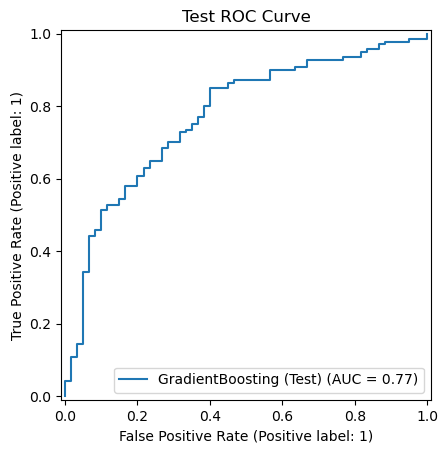

In [67]:
plt.figure()
RocCurveDisplay.from_predictions(
    y_test, y_proba_test, name=f"{best_name} (Test)")
plt.title("Test ROC Curve")
plt.show()

## 5 Top features and explain why

In [68]:
best_model.fit(X_tr, y_tr)


def get_feature_names(preprocessor, numeric_cols, categorical_cols):
    num_features = list(numeric_cols)
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_features = ohe.get_feature_names_out(categorical_cols).tolist()
    return num_features + cat_features


feature_names = get_feature_names(
    best_model.named_steps['prep'], numeric_cols, categorical_cols
)

perm = permutation_importance(
    best_model, X_val, y_val, n_repeats=20, random_state=42)

n_features = len(perm.importances_mean)
feature_names = feature_names[:n_features]

importances = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

top5 = importances.head(5)
display(top5)

,feature,importance_mean,importance_std
0,duration,0.05250,0.016771
3,residence_since,0.04125,0.011605
1,credit_amount,0.03425,0.020693
4,age,0.03050,0.017812
5,existing_credits,0.02425,0.008842


> 1. **Duration**
> Longer repayment periods increase the time window for unexpected events—such as job loss, illness, or economic downturns—that may lead to default.
> 
> 2. **Residence Since**
> This variable reflects **stability** and **rootedness**. A longer residence history suggests financial and social stability, whereas frequent moves may indicate instability or higher default risk.
> 
> 3. **Credit Amount**
> Larger loan amounts increase monthly repayment burdens and financial stress, especially if income does not scale proportionally.
> 
> 4. **Age**
> Age relates to **financial maturity**, **earning stability**, and **risk preferences**. Younger borrowers may have unstable income or less financial discipline, while very old borrowers might face income decline or fixed pensions.
> 
> 5. **Existing Credits**
> Multiple existing credits indicate **debt load** and **repayment obligations**. More open accounts can mean higher utilization, coordination costs, and potential over-indebtedness.
